#*importing libraries*

In [6]:
from scipy.io import arff
import pandas as pd

#*loading dataset*

In [9]:
data, meta = arff.loadarff("phpcFPMhq.arff")

df = pd.DataFrame(data)

In [10]:
df.head()

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Class
0,b'Sexy',b'Low',4.6,b'M',b'Summer',b'o-neck',b'sleevless',b'empire',b'?',b'chiffon',b'ruffles',b'animal',b'2'
1,b'Casual',b'Low',0.0,b'L',b'Summer',b'o-neck',b'Petal',b'natural',b'microfiber',b'?',b'ruffles',b'animal',b'1'
2,b'vintage',b'High',0.0,b'L',b'Automn',b'o-neck',b'full',b'natural',b'polyster',b'?',b'?',b'print',b'1'
3,b'Brief',b'Average',4.6,b'L',b'Spring',b'o-neck',b'full',b'natural',b'silk',b'chiffon',b'embroidary',b'print',b'2'
4,b'cute',b'Low',4.5,b'M',b'Summer',b'o-neck',b'butterfly',b'natural',b'chiffonfabric',b'chiffon',b'bow',b'dot',b'1'


# renaming the column

In [11]:
df.columns = [
    "Style",
    "Price",
    "Rating",
    "Size",
    "Season",
    "NeckLine",
    "SleeveLength",
    "WaistLine",
    "Material",
    "FabricType",
    "Decoration",
    "PatternType",
    "Recommendation"
]

In [12]:
df.head()

,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,WaistLine,Material,FabricType,Decoration,PatternType,Recommendation
0,b'Sexy',b'Low',4.6,b'M',b'Summer',b'o-neck',b'sleevless',b'empire',b'?',b'chiffon',b'ruffles',b'animal',b'2'
1,b'Casual',b'Low',0.0,b'L',b'Summer',b'o-neck',b'Petal',b'natural',b'microfiber',b'?',b'ruffles',b'animal',b'1'
2,b'vintage',b'High',0.0,b'L',b'Automn',b'o-neck',b'full',b'natural',b'polyster',b'?',b'?',b'print',b'1'
3,b'Brief',b'Average',4.6,b'L',b'Spring',b'o-neck',b'full',b'natural',b'silk',b'chiffon',b'embroidary',b'print',b'2'
4,b'cute',b'Low',4.5,b'M',b'Summer',b'o-neck',b'butterfly',b'natural',b'chiffonfabric',b'chiffon',b'bow',b'dot',b'1'


# decode the string byte

In [13]:
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)


In [14]:
df.head()

,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,WaistLine,Material,FabricType,Decoration,PatternType,Recommendation
0,Sexy,Low,4.6,M,Summer,o-neck,sleevless,empire,?,chiffon,ruffles,animal,2
1,Casual,Low,0.0,L,Summer,o-neck,Petal,natural,microfiber,?,ruffles,animal,1
2,vintage,High,0.0,L,Automn,o-neck,full,natural,polyster,?,?,print,1
3,Brief,Average,4.6,L,Spring,o-neck,full,natural,silk,chiffon,embroidary,print,2
4,cute,Low,4.5,M,Summer,o-neck,butterfly,natural,chiffonfabric,chiffon,bow,dot,1


# replacing the missing values[?]

In [15]:
import numpy as np

df.replace("?", np.nan, inplace=True)

In [16]:
df.head()

,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,WaistLine,Material,FabricType,Decoration,PatternType,Recommendation
0,Sexy,Low,4.6,M,Summer,o-neck,sleevless,empire,NaN,chiffon,ruffles,animal,2
1,Casual,Low,0.0,L,Summer,o-neck,Petal,natural,microfiber,NaN,ruffles,animal,1
2,vintage,High,0.0,L,Automn,o-neck,full,natural,polyster,NaN,NaN,print,1
3,Brief,Average,4.6,L,Spring,o-neck,full,natural,silk,chiffon,embroidary,print,2
4,cute,Low,4.5,M,Summer,o-neck,butterfly,natural,chiffonfabric,chiffon,bow,dot,1


# checking the missing values

In [17]:
df.isnull().sum()

,0
Style,0
Price,2
Rating,0
Size,0
Season,2
NeckLine,3
SleeveLength,2
WaistLine,87
Material,128
FabricType,266


In [18]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.head()

,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,WaistLine,Material,FabricType,Decoration,PatternType,Recommendation
0,Sexy,Low,4.6,M,Summer,o-neck,sleevless,empire,cotton,chiffon,ruffles,animal,2
1,Casual,Low,0.0,L,Summer,o-neck,Petal,natural,microfiber,chiffon,ruffles,animal,1
2,vintage,High,0.0,L,Automn,o-neck,full,natural,polyster,chiffon,lace,print,1
3,Brief,Average,4.6,L,Spring,o-neck,full,natural,silk,chiffon,embroidary,print,2
4,cute,Low,4.5,M,Summer,o-neck,butterfly,natural,chiffonfabric,chiffon,bow,dot,1


In [20]:
df.isnull().sum()

,0
Style,0
Price,0
Rating,0
Size,0
Season,0
NeckLine,0
SleeveLength,0
WaistLine,0
Material,0
FabricType,0


# checking duplicates

In [21]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# dataset information

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Style           500 non-null    object 
 1   Price           500 non-null    object 
 2   Rating          500 non-null    float64
 3   Size            500 non-null    object 
 4   Season          500 non-null    object 
 5   NeckLine        500 non-null    object 
 6   SleeveLength    500 non-null    object 
 7   WaistLine       500 non-null    object 
 8   Material        500 non-null    object 
 9   FabricType      500 non-null    object 
 10  Decoration      500 non-null    object 
 11  PatternType     500 non-null    object 
 12  Recommendation  500 non-null    object 
dtypes: float64(1), object(12)
memory usage: 50.9+ KB


In [23]:
df.describe(include='all')

,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,WaistLine,Material,FabricType,Decoration,PatternType,Recommendation
count,500,500,500.000000,500,500,500,500,500,500,500,500,500,500
unique,13,7,NaN,7,8,16,17,4,23,22,24,14,2
top,Casual,Average,NaN,M,Summer,o-neck,sleevless,natural,cotton,chiffon,lace,solid,1
freq,232,254,NaN,177,161,274,225,391,280,401,306,312,290
mean,NaN,NaN,3.528600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,2.005364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#perform anlaysis

top style dress

In [24]:
df["Style"].value_counts()

,count
Style,
Casual,232
Sexy,69
party,51
cute,45
vintage,25
bohemian,24
Brief,18
work,17
Novelty,8


price distribution

In [25]:
df["Price"].value_counts()

,count
Price,
Average,254
Low,129
low,45
Medium,30
very-high,21
high,15
High,6


Seasonal distribution

In [26]:
df["Season"].value_counts()

,count
Season,
Summer,161
Spring,122
Winter,99
Automn,61
winter,46
Autumn,8
spring,2
summer,1


recommendation distribution

In [27]:
df["Recommendation"].value_counts()

,count
Recommendation,
1,290
2,210


#**Visualizing the dataset**

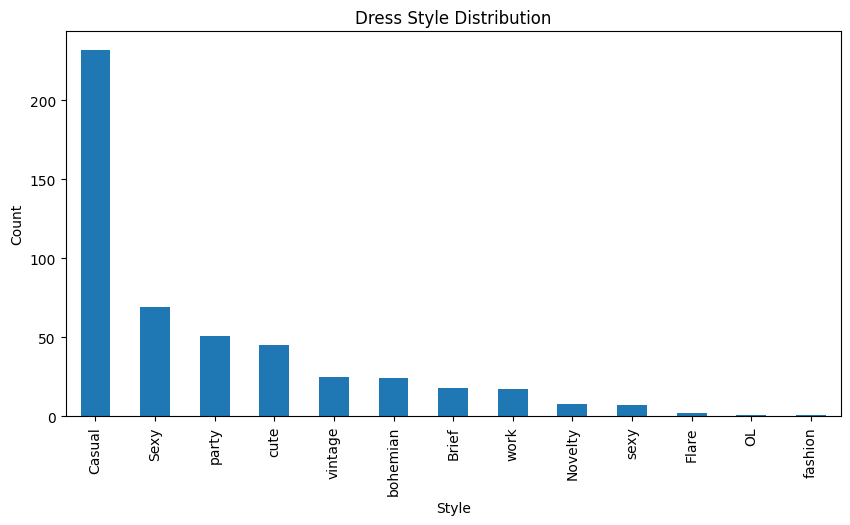

In [28]:
import matplotlib.pyplot as plt

df["Style"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Dress Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")
plt.show()

# Saving the cleaned dataset & downloading the cleaned dataset


In [29]:
df.to_csv("Dress_Recommendation_Cleaned.csv", index=False)

In [30]:
from google.colab import files

files.download("Dress_Recommendation_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>